In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pip install ucimlrepo

In [4]:
from ucimlrepo import fetch_ucirepo
bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
Y = bank_marketing.data.targets

In [5]:
X.isna().sum() # Verificando valores nulos o basura

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day_of_week,0


In [6]:
X = X.dropna(subset = ["job", "education"]) # Eliminando valores nulos
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
5,35,management,married,tertiary,no,231,yes,no,NaN,5,may,139,1,-1,0,NaN
6,28,management,single,tertiary,no,447,yes,yes,NaN,5,may,217,1,-1,0,NaN


In [7]:
# Eliminando columnas basura
X = X.drop("contact", axis=1)
X = X.drop("poutcome", axis=1)
X.head()

,age,job,marital,education,default,balance,housing,loan,day_of_week,month,duration,campaign,pdays,previous
0,58,management,married,tertiary,no,2143,yes,no,5,may,261,1,-1,0
1,44,technician,single,secondary,no,29,yes,no,5,may,151,1,-1,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,76,1,-1,0
5,35,management,married,tertiary,no,231,yes,no,5,may,139,1,-1,0
6,28,management,single,tertiary,no,447,yes,yes,5,may,217,1,-1,0


In [8]:
X.isna().sum() # Revisando la calidad de los datos de nuevo antes de continuar con el analisis

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
day_of_week,0
month,0


In [9]:
datos = X.join(Y)
datos

,age,job,marital,education,default,balance,housing,loan,day_of_week,month,duration,campaign,pdays,previous,y
0,58,management,married,tertiary,no,2143,yes,no,5,may,261,1,-1,0,no
1,44,technician,single,secondary,no,29,yes,no,5,may,151,1,-1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,76,1,-1,0,no
5,35,management,married,tertiary,no,231,yes,no,5,may,139,1,-1,0,no
6,28,management,single,tertiary,no,447,yes,yes,5,may,217,1,-1,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,17,nov,977,3,-1,0,yes
45207,71,retired,divorced,primary,no,1729,no,no,17,nov,456,2,-1,0,yes
45208,72,retired,married,secondary,no,5715,no,no,17,nov,1127,5,184,3,yes
45209,57,blue-collar,married,secondary,no,668,no,no,17,nov,508,4,-1,0,no


In [10]:
Y = datos[['y']]
Y

,y
0,no
1,no
2,no
5,no
6,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


In [11]:
X = datos.drop("y", axis=1)
X

,age,job,marital,education,default,balance,housing,loan,day_of_week,month,duration,campaign,pdays,previous
0,58,management,married,tertiary,no,2143,yes,no,5,may,261,1,-1,0
1,44,technician,single,secondary,no,29,yes,no,5,may,151,1,-1,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,76,1,-1,0
5,35,management,married,tertiary,no,231,yes,no,5,may,139,1,-1,0
6,28,management,single,tertiary,no,447,yes,yes,5,may,217,1,-1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,17,nov,977,3,-1,0
45207,71,retired,divorced,primary,no,1729,no,no,17,nov,456,2,-1,0
45208,72,retired,married,secondary,no,5715,no,no,17,nov,1127,5,184,3
45209,57,blue-collar,married,secondary,no,668,no,no,17,nov,508,4,-1,0


In [12]:
X = pd.get_dummies(X, columns=['job', 'marital'])
X

,age,education,default,balance,housing,loan,day_of_week,month,duration,campaign,...,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single
0,58,tertiary,no,2143,yes,no,5,may,261,1,...,True,False,False,False,False,False,False,False,True,False
1,44,secondary,no,29,yes,no,5,may,151,1,...,False,False,False,False,False,True,False,False,False,True
2,33,secondary,no,2,yes,yes,5,may,76,1,...,False,False,False,False,False,False,False,False,True,False
5,35,tertiary,no,231,yes,no,5,may,139,1,...,True,False,False,False,False,False,False,False,True,False
6,28,tertiary,no,447,yes,yes,5,may,217,1,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,tertiary,no,825,no,no,17,nov,977,3,...,False,False,False,False,False,True,False,False,True,False
45207,71,primary,no,1729,no,no,17,nov,456,2,...,False,True,False,False,False,False,False,True,False,False
45208,72,secondary,no,5715,no,no,17,nov,1127,5,...,False,True,False,False,False,False,False,False,True,False
45209,57,secondary,no,668,no,no,17,nov,508,4,...,False,False,False,False,False,False,False,False,True,False


In [13]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()

In [14]:
X.loc[:,"default"] = encoder.fit_transform(X[["default"]])
X.loc[:,"housing"] = encoder.fit_transform(X[["housing"]])
X.loc[:,"loan"] = encoder.fit_transform(X[["loan"]])
X

,age,education,default,balance,housing,loan,day_of_week,month,duration,campaign,...,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single
0,58,tertiary,0.0,2143,1.0,0.0,5,may,261,1,...,True,False,False,False,False,False,False,False,True,False
1,44,secondary,0.0,29,1.0,0.0,5,may,151,1,...,False,False,False,False,False,True,False,False,False,True
2,33,secondary,0.0,2,1.0,1.0,5,may,76,1,...,False,False,False,False,False,False,False,False,True,False
5,35,tertiary,0.0,231,1.0,0.0,5,may,139,1,...,True,False,False,False,False,False,False,False,True,False
6,28,tertiary,0.0,447,1.0,1.0,5,may,217,1,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,tertiary,0.0,825,0.0,0.0,17,nov,977,3,...,False,False,False,False,False,True,False,False,True,False
45207,71,primary,0.0,1729,0.0,0.0,17,nov,456,2,...,False,True,False,False,False,False,False,True,False,False
45208,72,secondary,0.0,5715,0.0,0.0,17,nov,1127,5,...,False,True,False,False,False,False,False,False,True,False
45209,57,secondary,0.0,668,0.0,0.0,17,nov,508,4,...,False,False,False,False,False,False,False,False,True,False


In [15]:
map_dict = {"primary":1, "secondary":2, "tertiary":3}
X["education"] = X["education"].map(map_dict)
X

,age,education,default,balance,housing,loan,day_of_week,month,duration,campaign,...,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single
0,58,3,0.0,2143,1.0,0.0,5,may,261,1,...,True,False,False,False,False,False,False,False,True,False
1,44,2,0.0,29,1.0,0.0,5,may,151,1,...,False,False,False,False,False,True,False,False,False,True
2,33,2,0.0,2,1.0,1.0,5,may,76,1,...,False,False,False,False,False,False,False,False,True,False
5,35,3,0.0,231,1.0,0.0,5,may,139,1,...,True,False,False,False,False,False,False,False,True,False
6,28,3,0.0,447,1.0,1.0,5,may,217,1,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,3,0.0,825,0.0,0.0,17,nov,977,3,...,False,False,False,False,False,True,False,False,True,False
45207,71,1,0.0,1729,0.0,0.0,17,nov,456,2,...,False,True,False,False,False,False,False,True,False,False
45208,72,2,0.0,5715,0.0,0.0,17,nov,1127,5,...,False,True,False,False,False,False,False,False,True,False
45209,57,2,0.0,668,0.0,0.0,17,nov,508,4,...,False,False,False,False,False,False,False,False,True,False


In [16]:
map_dict = {"jan":1, "feb":2, "mar":3, "apr":4, "may":5, "jun":6, "jul":7, "aug":8, "sep":9, "oct":10, "nov":11, "dec":12}
X["month"] = X["month"].map(map_dict)
X

,age,education,default,balance,housing,loan,day_of_week,month,duration,campaign,...,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single
0,58,3,0.0,2143,1.0,0.0,5,5,261,1,...,True,False,False,False,False,False,False,False,True,False
1,44,2,0.0,29,1.0,0.0,5,5,151,1,...,False,False,False,False,False,True,False,False,False,True
2,33,2,0.0,2,1.0,1.0,5,5,76,1,...,False,False,False,False,False,False,False,False,True,False
5,35,3,0.0,231,1.0,0.0,5,5,139,1,...,True,False,False,False,False,False,False,False,True,False
6,28,3,0.0,447,1.0,1.0,5,5,217,1,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,3,0.0,825,0.0,0.0,17,11,977,3,...,False,False,False,False,False,True,False,False,True,False
45207,71,1,0.0,1729,0.0,0.0,17,11,456,2,...,False,True,False,False,False,False,False,True,False,False
45208,72,2,0.0,5715,0.0,0.0,17,11,1127,5,...,False,True,False,False,False,False,False,False,True,False
45209,57,2,0.0,668,0.0,0.0,17,11,508,4,...,False,False,False,False,False,False,False,False,True,False


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((34554, 26), (8639, 26), (34554, 1), (8639, 1))

In [18]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)
pd.DataFrame(model.get_params().items())

,0,1
0,ccp_alpha,0.0
1,class_weight,None
2,criterion,gini
3,max_depth,None
4,max_features,None
5,max_leaf_nodes,None
6,min_impurity_decrease,0.0
7,min_samples_leaf,1
8,min_samples_split,2
9,min_weight_fraction_leaf,0.0


In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [21]:
cm = confusion_matrix(Y_test, y_pred)
cm

array([[7107,  551],
       [ 507,  474]])

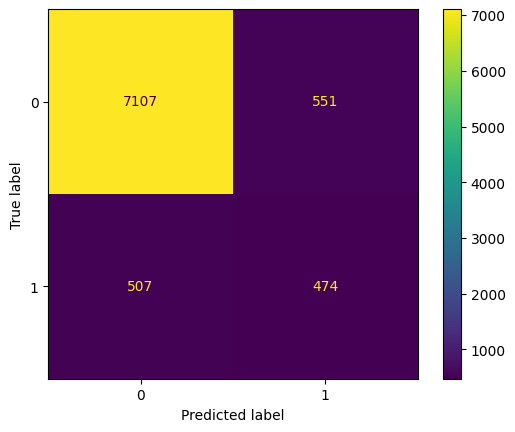

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [23]:
# precision de los datos
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test, y_pred)
accuracy

0.8775321217733534

In [24]:
X.shape, Y.shape

((43193, 26), (43193, 1))

In [25]:
datos = X.join(Y)
datos.shape

(43193, 27)

In [26]:
# Balanceo de datos

In [27]:
datos_true = datos[datos.y == "yes"]
datos_true.shape

(5021, 27)

In [28]:
datos_false = datos[datos.y == "no"]
datos_false.shape

(38172, 27)

In [29]:
datos_false = datos_false.sample(n = len(datos_true))
datos_false.shape

(5021, 27)

In [30]:
datos = pd.concat([datos_true, datos_false])
datos = datos.reset_index(drop=True)
datos.shape

(10042, 27)

In [31]:
datos.sample(n = 10)

,age,education,default,balance,housing,loan,day_of_week,month,duration,campaign,...,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_divorced,marital_married,marital_single,y
3776,34,2,0.0,15,0.0,0.0,12,1,377,1,...,False,False,False,False,False,True,False,False,True,yes
2257,39,3,1.0,3,0.0,0.0,6,5,488,1,...,False,False,False,False,True,False,True,False,False,yes
7867,40,2,0.0,2284,1.0,0.0,16,4,100,1,...,False,False,True,False,False,False,False,False,True,no
2331,59,3,0.0,148,1.0,1.0,8,5,685,2,...,True,False,False,False,False,False,False,True,False,yes
4429,32,3,0.0,46,1.0,0.0,14,6,485,2,...,False,True,False,False,False,False,False,False,True,yes
3453,51,2,0.0,371,1.0,1.0,21,10,287,1,...,False,False,False,False,True,False,False,True,False,yes
8252,39,2,0.0,369,0.0,1.0,20,11,224,1,...,False,False,False,False,False,False,False,False,True,no
5282,31,2,0.0,222,1.0,0.0,13,5,168,2,...,False,False,True,False,False,False,False,False,True,no
4367,52,3,0.0,388,0.0,0.0,25,5,272,1,...,False,False,False,False,False,False,False,True,False,yes
635,32,2,0.0,-46,0.0,1.0,18,7,1373,4,...,False,False,False,False,False,False,True,False,False,yes


In [32]:
y_new = datos[['y']]
X_new = datos.drop("y", axis=1)
X_new.shape, y_new.shape

((10042, 26), (10042, 1))

In [33]:
X_train, X_test = train_test_split(X_new, test_size=0.2, random_state=42)
Y_train, Y_test = train_test_split(y_new, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((8033, 26), (2009, 26), (8033, 1), (2009, 1))

In [34]:
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

In [35]:
cm = confusion_matrix(Y_test, y_pred)
cm

array([[783, 216],
       [228, 782]])

In [37]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

In [39]:
y_new = np.ravel(y_new)

In [43]:
# lista de hyper params que se probaran (es la libreria que se encarga de combinarlos)
param_grid = [
    {'max_depth' : [2, 5, 10],
     'min_samples_leaf': [10, 25, 50],
     'criterion': ['gini', 'entropy']
    }]

# se configura el modelo a utilizar, junto con su lista de hyper params
model = GridSearchCV(DecisionTreeClassifier(), param_grid, n_jobs=-1)
model.fit(X_new, y_new)

# validacion cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True)

# obtencion precisa y balanceada
accuracy = cross_val_score(model, X_new, y_new, cv=cv, scoring="balanced_accuracy")
print("Mejor modelo: {}".format(round(np.mean(accuracy), 3)))
print("Mejores parametros: {}".format(model.best_params_))


Mejor modelo: 0.818
Mejores parametros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 50}


In [48]:
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(model, X_new, y_new, cv=cv)
cm = confusion_matrix(y_new, y_pred)
cm

array([[3922, 1099],
       [ 759, 4262]])

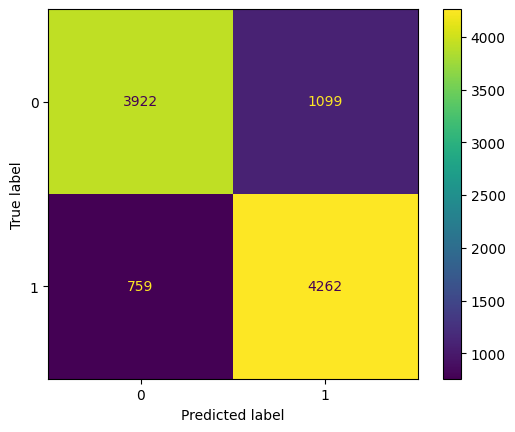

In [49]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [50]:
accuracy = accuracy_score(y_new, y_pred)
accuracy

0.8149770961959769

In [52]:
import pickle
filename = 'finalized_bank_marketing_model.sav'
pickle.dump(model, open(filename, 'wb'))